In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("climate.csv")
df.head(5)


,Year,CO2_Emissions,Forest_Loss,Energy_Consumption,Industrial_Index,Temperature_Rise
0,1991,21.0,0.80,320,45,0.18
1,1992,21.3,0.82,325,46,0.19
2,1993,21.6,0.85,330,47,0.20
3,1994,22.0,0.88,335,48,0.21
4,1995,22.4,0.90,340,49,0.22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                35 non-null     int64  
 1   CO2_Emissions       35 non-null     float64
 2   Forest_Loss         35 non-null     float64
 3   Energy_Consumption  35 non-null     int64  
 4   Industrial_Index    35 non-null     int64  
 5   Temperature_Rise    35 non-null     float64
dtypes: float64(3), int64(3)
memory usage: 1.8 KB


In [4]:
df.describe()

,Year,CO2_Emissions,Forest_Loss,Energy_Consumption,Industrial_Index,Temperature_Rise
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2008.000000,28.611429,1.909714,456.000000,62.028571,0.386000
std,10.246951,4.961070,0.881768,96.792683,10.297018,0.132403
min,1991.000000,21.000000,0.800000,320.000000,45.000000,0.180000
25%,1999.500000,24.250000,1.075000,365.000000,53.500000,0.275000
50%,2008.000000,28.500000,1.800000,450.000000,62.000000,0.380000
75%,2016.500000,32.750000,2.650000,535.000000,70.500000,0.495000
max,2025.000000,37.000000,3.500000,640.000000,80.000000,0.610000


In [5]:
df.isnull().sum()

Year                  0
CO2_Emissions         0
Forest_Loss           0
Energy_Consumption    0
Industrial_Index      0
Temperature_Rise      0
dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = df.drop("Temperature_Rise", axis=1)
y = df["Temperature_Rise"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 1.85178788228101e-05
R2 Score: 0.9964666041187006


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
future_data = pd.DataFrame({
    'Year': [2025],
    'CO2_Emissions': [38],
    'Forest_Loss': [3.3],
    'Energy_Consumption': [650],
    'Industrial_Index': [85]
})
future_temp = model.predict(future_data)
print("Predicted Temperature Rise:", round(future_temp[0], 2), "°C")

Predicted Temperature Rise: 0.68 °C


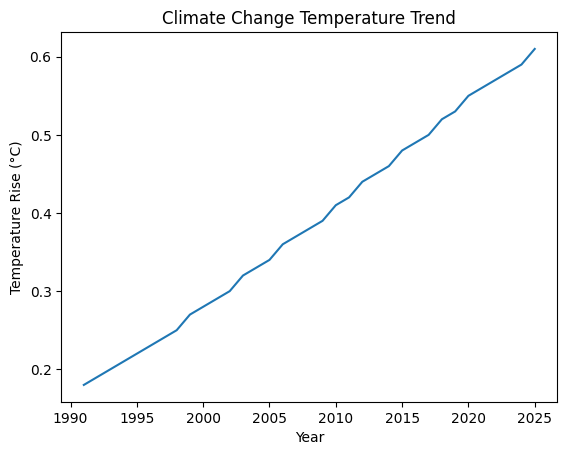

In [10]:
plt.plot(df['Year'], df['Temperature_Rise'])
plt.xlabel("Year")
plt.ylabel("Temperature Rise (°C)")
plt.title("Climate Change Temperature Trend")
plt.show()

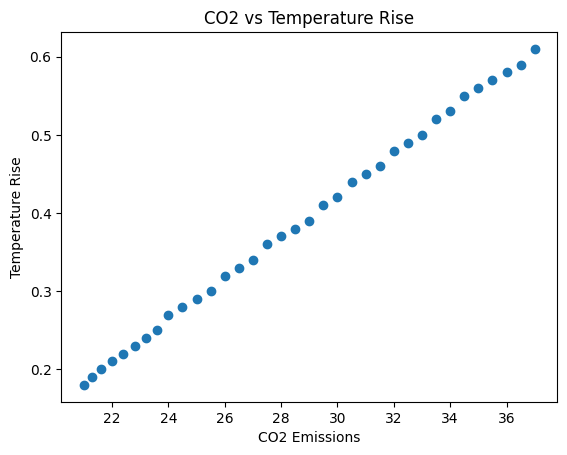

In [11]:
plt.scatter(df['CO2_Emissions'], df['Temperature_Rise'])
plt.xlabel("CO2 Emissions")
plt.ylabel("Temperature Rise")
plt.title("CO2 vs Temperature Rise")
plt.show()

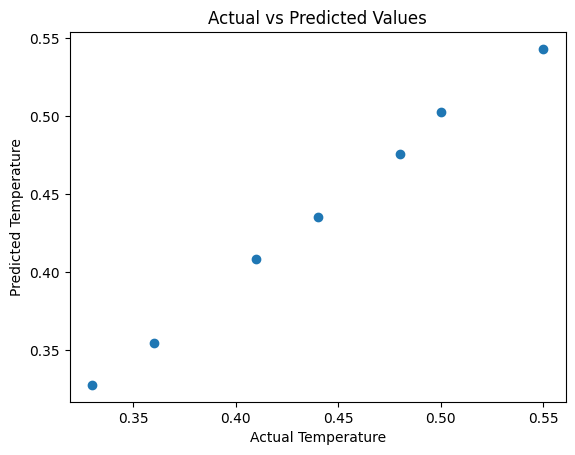

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Values")
plt.show()